In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ground truth
ALPHA_TRUE = 0.01
MU_TRUE = 0.48
D_TRUE = 0.038461538461538464*MU_TRUE

# Load CSV
df = pd.read_csv("recovery_tests/grid/alpha_mu.csv")

# Extract unique grid values (sorted!)
alphas = np.sort(df["alpha"].unique())
mus    = np.sort(df["mu"].unique())

A = len(alphas)
M = len(mus)

print(A, M)  # sanity check: should be 25 x 25


10 10


In [2]:
LL = np.full((A, M), np.nan)

alpha_to_i = {a: i for i, a in enumerate(alphas)}
mu_to_j    = {m: j for j, m in enumerate(mus)}

for _, row in df.iterrows():
    i = alpha_to_i[row.alpha]
    j = mu_to_j[row.mu]
    LL[i, j] = row.loglike


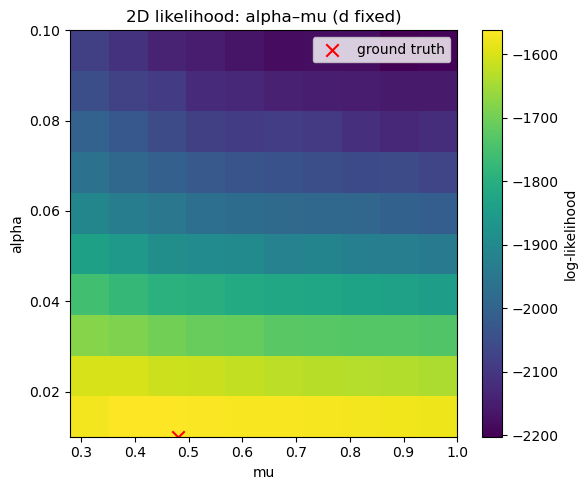

In [3]:
plt.figure(figsize=(6, 5))

im = plt.imshow(
    LL,
    origin="lower",
    aspect="auto",
    extent=[mus.min(), mus.max(), alphas.min(), alphas.max()],
)

plt.colorbar(im, label="log-likelihood")

plt.xlabel("mu")
plt.ylabel("alpha")
plt.title("2D likelihood: alpha–mu (d fixed)")

# Mark ground truth
plt.scatter(
    MU_TRUE,
    ALPHA_TRUE,
    color="red",
    marker="x",
    s=80,
    label="ground truth",
)

plt.legend()
plt.tight_layout()
plt.show()


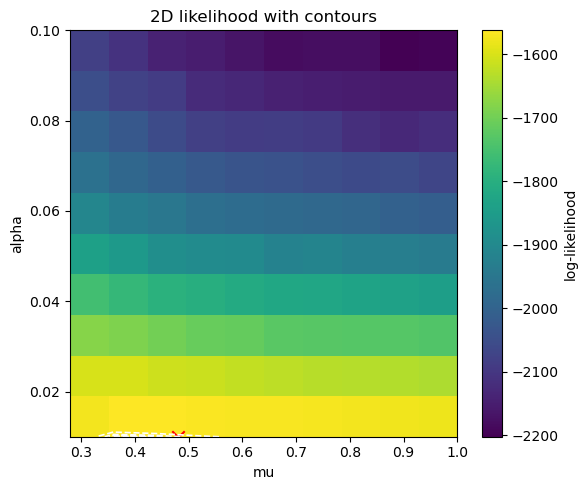

In [6]:
plt.figure(figsize=(6, 5))

X, Y = np.meshgrid(mus, alphas)

levels = np.sort(np.nanmax(LL) - np.array([0.5, 1.0, 2.0, 4.0]))

plt.contour(
    X, Y, LL,
    levels=levels,
    colors="white",
    linewidths=1.2,
)

im = plt.imshow(
    LL,
    origin="lower",
    aspect="auto",
    extent=[mus.min(), mus.max(), alphas.min(), alphas.max()],
)

plt.colorbar(im, label="log-likelihood")

plt.scatter(MU_TRUE, ALPHA_TRUE, color="red", marker="x", s=80)

plt.xlabel("mu")
plt.ylabel("alpha")
plt.title("2D likelihood with contours")

plt.tight_layout()
plt.show()
